# Controllo ottimo di un macchinario di produzione di neve artificiale
---

## Descrizione e formulazione del problema

- **Orizzonte temporale**  
  $t=0,1,...T$, $T = 72$ ore considerando un time step orario.
  
- **Stato**  
  $x_t=(temperatura\_ora\_t,umidità\_ora\_t,livello\_neve\_ora\_t) = (T_t,RH_t,d_t) = (i,j,k)$
   
- **Spazio degli stati**  
  $x_t \in X_f=\{(i,j,k): i=1,...,30, j=1,...,30, k=1,...,201\}_f$ --> uno spazio diverso per ogni fascia oraria $f$.
    - Le **fasce orarie** sono così definite: fascia 0 --> 00:00 - 00:59, ... , fascia 23 --> 23:00 - 23:59.
    - $T_t \in\{T_1,...,T_{30}\}_f$
        - $T_t$ variabile aleatoria discreta che assume valori discretizzati diversi a seconda della fascia oraria $f$ (con $f=0,...,23$) a cui l'istante $t$ appartiene, espressa in °C.
        - $T_t$ caratterizzata da $P(T_{t+1}=T_i|T_{t}=T_j)_f$ per ogni $(i,j)$, con $i=1,...,30$ e $j=1,...,30$
        - dove $P(.)_f$ è una matrice delle probabilità condizionate, diversa a seconda della fascia oraria $f$ a cui appartiene l'istante di tempo $t$.
    - $RH_t \in\{RH_1,...,RH_{30}\}_f$
        - $RH_t$ variabile aleatoria discreta che assume valori discretizzati diversi a seconda della fascia oraria $f$ (con $f=0,...,23$) a cui l'istante $t$ appartiene, espressa in termini percentuali.
        - $RH_t$ caratterizzata da $P(RH_{t+1}=RH_i|RH_{t}=RH_j)_f$ per ogni $(i,j)$, con $i=1,...,30$ e $j=1,...,30$
        - dove $P(.)_f$ è una matrice delle probabilità condizionate, diversa a seconda della fascia oraria $f$ a cui appartiene l'istante di tempo $t$.
    - Le probabilità sono stimate a partire da dati storici di temperatura e umidità osservati in un periodo di 2 mesi in una località sciistica americana, avendo a disposizione dati con frequenza oraria rilevati da un gruppo di 9 sensori dislocati in una vasta area.
    - $d_t \in D=\{0,...,max_d\}, |D|=n$ 
        - $d_t$ rappresenta la quantità di neve presente al suolo, espressa in metri cubi.
        - $max_d$ è il massimo quantitativo di neve, fissato a 100 $m^3.$
        - tiene conto della neve prodotta e della neve che si è fusa fino al time step t.

- **Stato iniziale**  
  $x_0 = (T_0,RH_0,d_0)$
    - dove $T_0$ e $RH_0$ sono campioni estratti secondo la pmf di temperatura e umidità relativa alla fascia oraria a cui appartiene l'istante temporale iniziale del time horizon. Si assume che la fascia oraria corrispondente a $t=0$ sia la fascia $0$,
    - e $d_0$ è impostato a $0 [m^3]$, assumendo che non sia presente neve al suolo all'inizio del time horizon.
  
- **Ingresso**  
  $u_t=(af_t,wf_t)$
    - $af_t$: flusso di aria iniettato nella macchina sparaneve nell'ora t, espresso in $[m^3/h]$.
    - $wf_t$: flusso di acqua iniettato nella macchina sparaneve nell'ora t, espresso in $[m^3/h]$.
- **Spazio degli ingressi**  
  $u_t \in U= 
    \begin{cases}
    \{(0,0)\} & \text{se } \text{la } \text{neve } \text{non } \text{può } \text{essere } \text{prodotta } \text{dati } (T_t,RH_t) \text{e } \text{se } d_t<max_d\\
    \{(min_{af},min_{wf}),...,(max_{af},max_{wf})\} & \text{altrimenti } 
    \end{cases}$
    - $min_{wf} = 0.6 [m^3/h], max_{wf} = [3.6,5.4] [m^3/h]$ (fissato a $4.5 [m^3/h]$)
        - step di discretizzazione: $0.2$
    - $min_{af} = 6 [m^3/h], max_{af} = 27 [m^3/h]$
        - step di dicretizzazione: $1$
    - la neve non può essere prodotta se la temperatura del bulbo umido (parametro che tiene conto di temperatura e umidità) è superiore alla soglia operativa $T_{wb,soglia} = -2.5 °C$;
    - la neve non può essere prodotta anche nel caso in cui sia già stata raggiunta la quantità di neve massima $max_d$ imposta dalla componente $d_t$ dello stato.
- **Dinamica del sistema - evoluzione delle componenti stato**  
  Le componenti $T_t$ e $RH_t$ evolvono secondo matrici di transizione delle probabilità.  
  La componente $d_t$ evolve secondo una funzione di transizione stocastica.
    - Evoluzione delle componenti **temperatura** e **umidità** dello stato
        - matrice di transizione per le componenti di temperatura e umidità dello stato, relativa alla fascia oraria $f$ a cui l'istante temporale $t$ appartiene
          $P((T_{t+1}=i',RH_{t+1}=j')|(T_{t}=i,RH_{t}=j))_f=P(T_{t+1}=i'|T_t=i)_f*P(RH_{t+1}=j'|RH_t=j)_f$
        - Abbiamo 24 matrici di transizione: una per ogni coppia consecutiva di fascie orarie più una matrice per la transizione dalla fascia 23 alla fascia 0.
        - È stata fatta l'assunzione dell'indipendenza tra temperatura e umidità all'interno della stessa fascia oraria.
  
    - Evoluzione della componente "**livello_neve**" dello stato 
        - la funzione si compone di 3 termini: il quantitativo precedente di neve al suolo ($d_t$), un termine che tiene conto della neve prodotta e un altro termine che tiene conto della della neve fusa durante un time step $t$:
        - $d_{t+1}=d_t+Neve\_prodotta(x_t,u_t)-Neve\_fusa(x_t)$
        - valore da approssimare al valore discreto più vicino assunto da $d_t$.
    - Funzione per determinare la **neve prodotta** in un time step in $m^3$
        - $Neve\_prodotta(x_t,u_t)=Neve\_prodotta(T_t,RH_t,af_t,wf_t)=k(T_t,RH_t)*min(af_t,wf_t)$
        - $k=\alpha * max(0,T_{wb,soglia}-T_{wb})$ coefficiente di efficienza
        - $\alpha:$ coefficiente calibrato $\in [0.4,1]$, caratteristico della macchina sparaneve
        - $T_{wb,soglia} = -2.5 °C$: soglia (wet-bulb) operativa del generatore
        - $T_{wb} ≈ T_t ⋅arctan(0.151977⋅(RH_t+8.313659)^{0.5})+arctan(T_t+RH_t)-arctan(RH_t−1.676331)
+0.00391838⋅RH^{1.5}⋅arctan(0.023101⋅RH)−4.686035$
        - dove $T_t$ in $°C$ e $RH_t$ in percentuale
    - Funzione per determinare la **neve fusa** in un time step in $m^3$
        - $Neve\_fusa(x_t)=Neve\_fusa(T_t,RH_t)= [(DHF * max(T_{t}-T_0,0) * humidity\_factor)/1000] * A$
        - $DHF = degree-hour-factor (mm/°C/ora)$ (impostata a 0.7)
        - $T_{t} = temperatura °C$ (che si verifica nell'ora attuale)
        - $RH_{t} = umidità %$ (che si verifica nell'ora attuale)
        - $humidity\_factor = 0.5 + 0.5 * RH_t$ 
        - $T_0 = soglia (≈°C)$ (impostata a $0°C$)
        - $A = area (m^2)$ (area occupata dalla neve al suolo, impostata a $30 m^2$)
- **Stage cost**  
  $g(u_t):$ deterministico, tempo-invariante
    - $g(u_t)=prezzo\_energia*(E_{ventola}+E_{compressore}(u_t)+E_{pompa}(u_t))$
    - $prezzo\_energia = 0.25 [\text{€}/kWh] $
    - $E_{ventola}=18.5 kWh$ costante.
        - Rappresenta l'energia consumata in un ora dalla ventola della macchina sparaneve.
    - $E_{compressore}(u_t)= e * af_t * 60$.
        - Rappresenta l'energia consumata in un ora dal commpressore che comprime l'aria prima che venga fornita alla macchina.
        - $e=6.2 [kW/(m^3/min)]$
        - $af_t [m^3/h]$
    - $E_{pompa}(u_t)=k_{pump}*wf_t$.
        - Rappresentra l'energia consumata in un ora dalla pompa che mette in pressione l'acqua prima di fornirla alla macchina.
        - $k_{pump}=2.7 [kWh/m^3]$
        - $wf_t [m^3/h]$
- **Terminal cost** $g_T(x_T)$:
    - costo pari a un costo di penalizzazione se il livello di neve al suolo non raggiunge almeno i $40 [m^3]$ di neve al termine dell'orizzonte temporale
    - $g_T((i,j,k)) = \begin{cases} 0 & \text{if } k \geq 80 \\ 5*10^3 & \text{if } k < 80  \end{cases}$
    - dove 80 è l'indice corrispondente al valore di 40 $m^3$ nello spazio $D$ in cui è definita $d_t$.

## Formulazione del problema
---

### Importazione moduli

In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import json
import math 
from functions import *
from numba import njit, prange
import os

### Parametri del problema

In [2]:
# Stato
n_fasce=24 #fasce orarie
n_T = 30 #numero di intervalli di discretizzazione di temperatura
n_RH = 30 #numero di intervalli di discretizzazione di umidità
n_T_RH = n_T * n_RH #numero di possibili combinazioni di temperatura e umidità per fascia oraria
max_d=100 #quantità massima della neve in m^3
step_d=0.5 #step di discretizzazione del livello di neve
# Ingresso
# - flusso di aria minimo e massimo in ingresso allo sparaneve
min_af=6
max_af=27
af_step=1 #step di discretizzazione del flusso di aria
# - flusso di acqua minimo e massimo in ingresso allo sparaneve
min_wf=0.6
max_wf=4.5 #[3.6,5.4]
wf_step=0.2 #step di discretizzazione del flusso di acqua
# Stato terminale
d_target=40 #livello di neve minimo che deve essere raggiunto in m^3
penalization_cost=5e3 #costo terminale nel caso in cui la quantità target di neve non venga raggiunta

### Caricamento dati meteorologici da file

In [3]:
# CARICAMENTO DATI temperatura e umidità DA FILE JSON
with open("pmf_temperature.json", "r", encoding="utf-8") as f1:
    temperature = json.load(f1)

with open("pmf_humidity.json", "r", encoding="utf-8") as f2:
    humidity = json.load(f2)

# conversione dei dizionari in numpy array
# - temperatura
temp_val=np.empty((n_fasce,n_T)) #valori discreti per fasce orarie
temp_pmf=np.empty((n_fasce,n_T)) #pmf per fasce orarie
f=0
for fasce,dict_val in temperature.items():
    temp_val[f]=np.array(dict_val['values'],dtype=np.float32)
    temp_pmf[f]=np.array(dict_val['pmf'],dtype=np.float32)
    f+=1
    
# - umidità
humid_val=np.empty((n_fasce,n_RH)) #valori discreti per fasce orarie
humid_pmf=np.empty((n_fasce,n_RH)) #pmf per fasce orarie
f=0
for fasce,dict_val in humidity.items():
    humid_val[f]=np.array(dict_val['values'],dtype=np.float32)
    humid_pmf[f]=np.array(dict_val['pmf'],dtype=np.float32)
    f+=1

# caricamento delle matrici delle probabilità condizionate da file
P_T_list = load_transition_matrices("transition_T.json") #lista di matrici P_T, una per ogni fascia oraria
P_RH_list = load_transition_matrices("transition_RH.json") #lista di matrici P_RH, una per ogni fascia oraria

print("Caricate", len(P_T_list), "matrici di transizione T")
print("Caricate", len(P_RH_list), "matrici di transizione RH")

Caricate 24 matrici di transizione T
Caricate 24 matrici di transizione RH


### Definizione spazio degli stati e degli ingressi 

In [4]:
# Definizione dello spazio dei valori discreti della quantità di neve
depth_space=np.arange(0,max_d+step_d,step_d,dtype=np.float32)
n_d=depth_space.shape[0] #numero di intervalli di discretizzazione della quantità della neve

# Spazio degli stati
state_space=np.empty((n_fasce,n_T,n_RH,n_d,3))
n_states=n_T*n_RH*n_d #numero di stati per fascia oraria
# - definizione di uno spazio degli stati per ogni fascia oraria
for f in range(n_fasce):
    X=np.empty((n_T,n_RH,n_d,3),dtype=np.float32)
    for i,T in enumerate(temp_val[f]):
        for j,RH in enumerate(humid_val[f]):
            for k,d in enumerate(depth_space):            
                X[i,j,k]=[T,RH,d]
    state_space[f]=X
print(state_space[0].shape)

# Spazio degli ingressi
# - flusso di aria
af_val=np.arange(min_af,max_af+af_step,af_step,dtype=np.float32)
af_n_val=af_val.shape[0] #numero di intervalli di discretizzazione del flusso di aria
# - flusso di acqua
wf_val=np.arange(min_wf,max_wf+wf_step,wf_step,dtype=np.float32)
wf_n_val=wf_val.shape[0] #numero di intervalli di discretizzazione delflusso di acqua
# - spazio degli ingressi di default, applicato nel caso in cui la temperatura wet-bulb sia al di sotto di -2.5°
U_default=np.empty((af_n_val*wf_n_val,2),dtype=np.float32)
for i,af in enumerate(af_val):
    for j,wf in enumerate(wf_val):
        U_default[i*wf_n_val+j]=[af,wf]

(30, 30, 201, 3)


### Definizione stage cost e terminal cost

In [5]:
@njit
def stage_cost(x_t,u_t):
    T_t=x_t[0]
    RH_t=x_t[1]
    af_t=u_t[0]
    wf_t=u_t[1]
    energy_price=0.25 #€/kWh
    E_fan=18.5 #kWh
    e=6.2 #kW/(m^3/min)
    E_compressor=e*af_t #kWh
    k_pump=2.7 #kWh/m^3 ~0.2–2.7 kWh/m³
    E_pump=k_pump*wf_t #kWh 
    return energy_price*(E_fan+E_compressor+E_pump)

@njit
def terminal_cost(x_T):
    d_t=x_T[2]
    if d_t<d_target:
        return penalization_cost
    else:
        return 0

### Definizione della dinamica del sistema
---

#### Matrici P per la transizione di temperatura e umidità

In [6]:
# Calcolo matrici P_t di transizione delle componenti temperatura e umidità dello stato
# --> P_list conterrà una matrice di transizione per fascia oraria [0-23] --> 24 matrici
P_list = np.empty((n_fasce,n_T_RH,n_T_RH))

for f in range(n_fasce):
    P_T = P_T_list[f] #matrice delle probabilità condizionate della temperatura relativa alla fascia f
    P_RH = P_RH_list[f] #matrice delle probabilità condizionate dell'umidità relativa alla fascia f
    P_list[f]=build_joint_transition(P_T, P_RH)

print(P_list[0].shape)

(900, 900)


#### Funzione per la transizione della quantità di neve al suolo

In [7]:
# - funzione di transizione per la componente 'livello_neve' dello stato 
@njit
def depth_transition(x_t,u_t):
    T_t=x_t[0]
    RH_t=x_t[1]
    d_t=x_t[2]
    af_t=u_t[0]
    wf_t=u_t[1]
    # quantità di neve al suolo al prossimo time step (fascia oraria)
    d_next=d_t+snow_produced(T_t,RH_t,af_t,wf_t)-snow_melted(T_t,RH_t)
    if d_next<0:
        d_next_discretized=np.float32(0)
    else: # arrotondamento al campione discreto più vicino
        d_next_discretized=depth_space[np.argmin(np.abs(depth_space-d_next))]
    return d_next_discretized

#### Stato iniziale

In [8]:
# - funzione che restituisce uno stato iniziale secondo le distribuzioni di temperatura e umidità nella fascia oraria iniziale
# - e secondo la quanità di neve al suolo iniziale passata come parametro
def get_initial_state(f_t0,d0):
    # --> f_t0: fascia oraria dell'istante di tempo iniziale t0 del time horizon
    # da aggiungere il controllo della fascia oraria
    pmf_T_t0=temp_pmf[f_t0] # pmf temperatura nella fascia f_t0
    pmf_RH_t0=humid_pmf[f_t0] # pmf umidità nella fascia f_t0
    T0=np.random.choice(temp_val[f_t0], p=pmf_T_t0) # estrazione di un campione di temperatura dalla relativa pmf
    RH0=np.random.choice(humid_val[f_t0], p=pmf_RH_t0) # estrazione di un campione di umidità dalla relativa pmf
    x_0=np.array([T0,RH0,d0],dtype=np.float32)
    return x_0

#### Evoluzione meteorologica del sistema

In [9]:
# - evoluzione di uno step per temperatura e umidità, secondo la matrice di transizione realtiva alla fascia f
def weather_transition(x_t,f):
    T_t=x_t[0]
    RH_t=x_t[1]
    # matrice di transizione relativa alla fascia f
    P_f = P_list[f] 
    # conversione stato in indice
    state_idx = state_to_index(T_t,RH_t,temp_val[f],humid_val[f])
    # estrazione di un campione secondo la pmf condizionata allo stato corrente, presente nella matrice P_f
    next_state_idx = np.random.choice(np.arange(0,n_T_RH,1), p=P_f[state_idx]) 
    # conversione indice ottenuto in stato
    if f<23:
        next_T, next_RH = index_to_state(next_state_idx,temp_val[f+1],humid_val[f+1])
    else: #siamo nell'ultima fascia oraria, i prossimi valori da considerare per temperatura e umidità vengono presi dalla fascia 0
        next_T, next_RH = index_to_state(next_state_idx,temp_val[0],humid_val[0])
    return next_T, next_RH

# - simulazione dell'andamento di temperatura e umidità per un singolo time horizon t=0,...,T
def simulate_weather_transition(T,print_enabled=False):
    # --> T: lunghezza time horizon
    X_sim=np.empty((T,2)) #lista degli stati (Temperatura,Umidità) visitati dal sistema durante la simulazione
    f_t0=0 #fascia oraria a cui appartiene t0
    x_0=get_initial_state(f_t0,depth_space[0]) #la profonditò della neve viene impostata a 0
    # inizializzazione
    u_t=np.array([0,0],dtype=np.float32)
    x_t=x_0
    f_t=f_t0
    # iterazione
    for t in range(T):
        next_T, next_RH = weather_transition(x_t,f_t)
        x_tp1 = np.array([next_T,next_RH],dtype=np.float32)
        X_sim[t]=x_tp1
        if print_enabled: print(f"time {t}, fascia {f_t}, T={x_tp1[0]:.2f} RH={x_tp1[1]:.2f}")
        x_t=x_tp1
        f_t=(t+1)%24
    return X_sim
# test della funzione
X_sim=simulate_weather_transition(72,print_enabled=True)

time 0, fascia 0, T=-5.81 RH=92.38
time 1, fascia 1, T=-5.45 RH=92.66
time 2, fascia 2, T=-5.22 RH=91.65
time 3, fascia 3, T=-5.58 RH=93.41
time 4, fascia 4, T=-2.37 RH=91.30
time 5, fascia 5, T=-2.34 RH=91.32
time 6, fascia 6, T=-2.43 RH=90.39
time 7, fascia 7, T=-1.46 RH=89.58
time 8, fascia 8, T=3.58 RH=92.11
time 9, fascia 9, T=2.84 RH=91.54
time 10, fascia 10, T=4.65 RH=87.95
time 11, fascia 11, T=5.97 RH=87.16
time 12, fascia 12, T=7.15 RH=86.84
time 13, fascia 13, T=6.83 RH=86.98
time 14, fascia 14, T=5.68 RH=81.86
time 15, fascia 15, T=4.65 RH=87.77
time 16, fascia 16, T=3.72 RH=88.24
time 17, fascia 17, T=1.54 RH=88.89
time 18, fascia 18, T=1.24 RH=91.71
time 19, fascia 19, T=1.74 RH=91.54
time 20, fascia 20, T=1.58 RH=91.69
time 21, fascia 21, T=2.29 RH=92.02
time 22, fascia 22, T=1.81 RH=92.29
time 23, fascia 23, T=-5.14 RH=92.22
time 24, fascia 0, T=-4.28 RH=92.38
time 25, fascia 1, T=-5.45 RH=92.66
time 26, fascia 2, T=-6.68 RH=91.65
time 27, fascia 3, T=-7.07 RH=91.23
tim

#### Plot andamento di temperatura e umidità durante il time horizon T

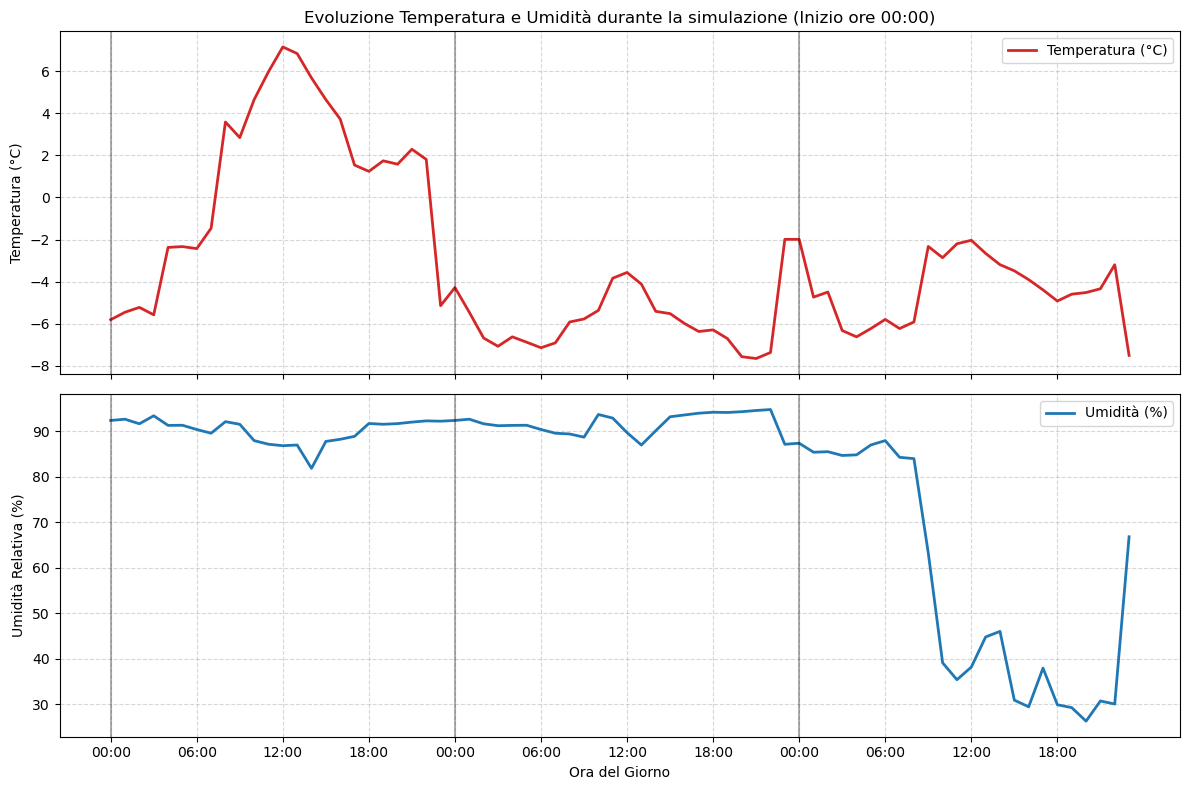

In [10]:
def plot_weather_simulation(X_sim, f_t0=0):
    # --> X_sim: array (T, 2) con i dati simulati
    # --> f_t0: l'ora della fascia oraria di partenza (default 0)
    T = len(X_sim)
    time_steps = np.arange(T)
    
    # Calcoliamo le ore del giorno reali per ogni step
    hours_of_day = [(f_t0 + t) % 24 for t in range(T)]
    
    # Creiamo delle etichette stringa per l'asse x (es. "14:00")
    # Ne mostriamo una ogni 6 ore per non affollare il grafico
    labels = [f"{h:02d}:00" for h in hours_of_day]
    
    temps = X_sim[:, 0]
    humidity = X_sim[:, 1]
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
    
    # Plot Temperatura
    ax1.plot(time_steps, temps, color='tab:red', linewidth=2, label='Temperatura (°C)')
    ax1.set_ylabel('Temperatura (°C)')
    ax1.grid(True, linestyle='--', alpha=0.5)
    ax1.legend(loc='upper right')
    ax1.set_title(f'Evoluzione Temperatura e Umidità durante la simulazione (Inizio ore {f_t0:02d}:00)')
    
    # Plot Umidità
    ax2.plot(time_steps, humidity, color='tab:blue', linewidth=2, label='Umidità (%)')
    ax2.set_ylabel('Umidità Relativa (%)')
    ax2.set_xlabel('Ora del Giorno')
    ax2.grid(True, linestyle='--', alpha=0.5)
    ax2.legend(loc='upper right')
    
    # --- Gestione Asse X ---
    # Decidiamo ogni quante ore mettere un "tick" (es. ogni 6 ore)
    step_tick = 6 
    tick_indices = np.arange(0, T, step_tick)
    plt.xticks(tick_indices, [labels[i] for i in tick_indices])
    
    # Aggiungiamo linee verticali tratteggiate per indicare la mezzanotte (cambio giorno)
    for t in range(T):
        if (f_t0 + t) % 24 == 0:
            ax1.axvline(x=t, color='black', linestyle='-', alpha=0.3)
            ax2.axvline(x=t, color='black', linestyle='-', alpha=0.3)

    plt.tight_layout()
    plt.show()

# utilizzo dei risultatio della precedente simulazione
simulation_results=X_sim
plot_weather_simulation(simulation_results, f_t0=0)

## Implementazione algoritmo DP
---

In [11]:
# funzione che esegue un singolo step dell'algoritmo di Dynamic Programming
@njit(parallel=True)
def dp_step(t, f_t, V_list, mu_star_list, temp_curr, humid_curr, depth_space, temp_next, humid_next, P_matrix_current, U_default):
    
    # Dimensioni
    n_T = len(temp_curr)
    n_RH = len(humid_curr)
    n_d = len(depth_space)
    
    n_T_next = len(temp_next)
    n_RH_next = len(humid_next)
    
    # Loop Parallelo sulla componente temperatura dello stato
    for i in prange(n_T):
        for j in range(n_RH):
            for k in range(n_d):
                
                # --- 1. Definizione dello Stato Corrente ---
                T = temp_curr[i]
                RH = humid_curr[j]
                d = depth_space[k]
                
                # Creiamo l'array x_t per le funzioni (stage_cost, transition)
                x_t = np.array([T, RH, d], dtype=np.float32)
                
                # --- 2. Recupero Input Ammissibili ---
                # Usiamo la tua input_space
                U_valid = input_space(T, RH, U_default,d,max_d)
                n_inputs = len(U_valid)
                
                # Variabili per trovare il minimo (logica argmin)
                best_total_cost = np.inf
                best_u = np.zeros(2, dtype=np.float32) # miglior ingresso trovato fino ad ora
                
                # Indice linearizzato per la matrice P (meteo corrente)
                idx_curr_weather = i * n_RH + j 
                
                # --- 3. Loop sulle Azioni (u) ---
                for u_idx in range(n_inputs):
                    u = U_valid[u_idx]
                    
                    # A. Costo dello stadio corrente
                    cost_stage = stage_cost(x_t, u)

                    # B. Calcolo dinamico dell'expected cost-to-go
                    d_next = depth_transition(x_t, u)
                    
                    # Trova indice k_next corrispondente
                    k_next = np.searchsorted(depth_space, d_next)
                    
                    # Clipping indici per sicurezza
                    if k_next >= n_d: k_next = n_d - 1
                    if k_next < 0: k_next = 0
                    
                    # Calcolo del valore atteso iterando sulle condizioni meterologiche future (Temperatura e Umidità)
                    E_cost_to_go = 0.0
                    
                    for i_next in range(n_T_next):
                        for j_next in range(n_RH_next):
                            
                            # Indice linearizzato meteo futuro
                            idx_next_weather = i_next * n_RH_next + j_next
                            
                            # Accesso alla probabilità di osservare questa precisa combinazione di temperatura e umidità
                            prob = P_matrix_current[idx_curr_weather, idx_next_weather]
                            
                            if prob > 1e-8: # si evita di trattare coppie che non sono probabili
                                val_next = V_list[t+1, i_next, j_next, k_next]
                                E_cost_to_go += prob * val_next
                    
                    # C. Totale e Aggiornamento Minimo
                    total_val = cost_stage + E_cost_to_go
                    
                    if total_val < best_total_cost:
                        best_total_cost = total_val
                        best_u = u 
                
                # --- 4. Salvataggio Risultati ---
                V_list[t, i, j, k] = best_total_cost
                mu_star_list[t, i, j, k, 0] = best_u[0]
                mu_star_list[t, i, j, k, 1] = best_u[1]

# DEFINIZIONE STRUTTURE DATI
# - ALLOCAZIONE ARRAY - state-value function e optimal policy
T=72 #lunghezza time horizon in ore
V_list=np.zeros((T+1,n_T,n_RH,n_d),dtype=np.float32) #lista di cost value functions, una per ogni istenate di tempo
mu_star_list=np.zeros((T,n_T,n_RH,n_d,2),dtype=np.float32)# policy da trovare, per ogni fascia oraria
print(V_list[0].shape)
print(mu_star_list[0].shape)

# - INIZIALIZZAZIONE ARRAY V_list
# loop over all the possible states
target_d_idx=np.where(depth_space == d_target)[0][0] #indice corrispondente al minimo quantitativo di neve da raggiungere al termine del time horizon
for i in range(n_T):
    for j in range(n_RH):
        for k in range(n_d): 
            if k<target_d_idx:
                V_list[T,i,j,k]=penalization_cost

@njit
def run_dp_algorithm(T,V,optimal_policy):    
    # ITERAZIONI
    # loop su tutti gli istanti di tempo in [T-1,...,0]
    for t in range(T-1,-1,-1): 
        print(f"Processing time {t}")
        f_t=t%24 #fascia a cui appartiene l'istante t
        # Determinazione array meteo corrente e prossimo
        temp_curr = temp_val[f_t]
        humid_curr = humid_val[f_t]
        # - se siamo all'ultima ora, il "next" è l'ora 0
        if f_t == 23: f_t_next=0
        else: f_t_next=f_t+1
        temp_next = temp_val[f_t_next]
        humid_next = humid_val[f_t_next]
        # Esecuzione singolo step di dp
        dp_step(t,f_t,V,optimal_policy,temp_curr,humid_curr,depth_space,temp_next,humid_next,P_list[f_t],U_default)

(30, 30, 201)
(30, 30, 201, 2)


## Esecuzione dell'algoritmo
---
L'algoritmo di DP viene eseguito se non è presente già il file con la policy ottimale.
In questo caso la policy viene caricata come numpy array.

In [12]:
filename = "optimal_policy.npy"
# Controlla se il file con la policy ottimale esiste o meno
if not os.path.exists(filename):
    print(f"File \"{filename}\" non trovato. Eseguo l'algoritmo di Dynamic Programming...")

    # Esecuzione algoritmo di DP
    run_dp_algorithm(T,V_list,mu_star_list)
    
    # Salvataggio della policy su file
    np.save(filename, mu_star_list)
    optimal_policy = mu_star_list
    print("Calcolo completato e file salvato.")
else:
    # Se il file esiste, viene caricato
    print(f"File \"{filename}\" trovato! Caricamento della policy ottimale in corso...")
    optimal_policy = np.load(filename)

File "optimal_policy.npy" trovato! Caricamento della policy ottimale in corso...


## Simulazione del sistema
---

### Funzione per simulare il sistema con la policy ottimale trovata

In [13]:
# - funzione per la simulazione del sistema 
def simulate(T,d0,policy,print_enabled=False):
    # --> T: lunghezza time horizon
    # --> d0: quantità di neve al suolo all'inizio del time horizon
    # --> policy: policy utilizzata per la selezione dell'ingresso del sistema
    X_sim=np.empty((T,3)) #lista degli stati visitati dal sistema durante la simulazione
    # INIZIALIZZAZIONE
    t0=0
    f_t0=t0%24 #fascia oraria a cui appartiene t0
    x_0=get_initial_state(f_t0,d0) #stato iniziale
    #calcolo indici corrispondenti alle componenti dello stato per indicizzare l'array della policy ottimale
    T_idx = np.searchsorted(temp_val[f_t0], x_0[0])
    RH_idx = np.searchsorted(humid_val[f_t0], x_0[1])
    d_idx = np.searchsorted(depth_space, x_0[2])
    u_t0=policy[t0,T_idx,RH_idx,d_idx,:] #selezione dell'ingresso iniziale in accordo alla policy ottimale
    total_cost = stage_cost(x_0,u_t0)
    # ITERAZIONI
    x_t=x_0
    u_t=u_t0
    f_t=f_t0
    for t in range(T):
        if print_enabled: print(f"time {t}, fascia {f_t}, T={x_t[0]:.2f} RH={x_t[1]:.2f}% d={x_t[2]:.2f}")
        #evoluzione componenti dello stato
        next_T, next_RH = weather_transition(x_t,f_t)
        next_d = depth_transition(x_t,u_t)
        #stato raggiunto all'istante t+1
        x_tp1 = np.array([next_T,next_RH,next_d],dtype=np.float32)
        X_sim[t]=x_tp1
        x_t=x_tp1
        f_t=(t+1)%24
        if t<=70: 
            if print_enabled: print(f"--> ingresso: air_flow={u_t[0]:.2f} water_flow=={u_t[1]:.2f}\n")
            #calcolo indici corrispondenti alle componenti dello stato per indicizzare l'array della policy ottimale
            T_next_idx = np.searchsorted(temp_val[f_t], x_t[0])
            RH_next_idx = np.searchsorted(humid_val[f_t], x_t[1])
            d_next_idx = np.searchsorted(depth_space, x_t[2])
            u_t=policy[t+1,T_next_idx,RH_next_idx,d_next_idx,:] #selezione dell'ingresso in accordo alla policy ottimale
            total_cost += stage_cost(x_t, u_t) #accumulazione stage cost
        else: #siamo alla fine del time horizon
            total_cost += terminal_cost(x_t) #accumulazione terminal cost
    if print_enabled: print(f"Costo totale: {total_cost:.2f}")
    return X_sim, total_cost

### Funzione per plottare l'evoluzione della quantità di neve al suolo 

In [14]:
def plot_snow_depth(X_sim,f_t0=0):
    # --> X_sim: array (T, 3) restituito dalla funzione simulate
    # --> f_t0: fascia di inizio della simulazione
    T = len(X_sim)
    time_steps = np.arange(T)
    
    # Estrazione del livello di neve
    snow_depth = X_sim[:, 2]
    
    # Calcolo delle ore per l'asse x del plot
    hours_of_day = [(f_t0 + t) % 24 for t in range(T)]
    labels = [f"{h:02d}:00" for h in hours_of_day]
    
    plt.figure(figsize=(12, 6))
    
    # Plot della quantità di neve simulata
    plt.plot(time_steps, snow_depth, color='tab:blue', linewidth=2.5, label='Livello neve (d)')
    
    # Riga orizzontale del corrispindente al target minimo da raggiungere
    plt.axhline(y=d_target, color='tab:red', linestyle='--', linewidth=2, label=f'Target (d={d_target})')
    
    # Formattazione grafica
    plt.title('Evoluzione della quantità di neve al suolo durante la simulazione', fontsize=14)
    plt.ylabel('Quantità di neve (m^3)', fontsize=12) 
    plt.xlabel('Ora del Giorno', fontsize=12)
    
    # Gestione delle barre verticali dell'asse x (una ogni 6 ore)
    step_tick = 6
    tick_indices = np.arange(0, T, step_tick)
    plt.xticks(tick_indices, [labels[i] for i in tick_indices])
    
    # Linee verticali per la mezzanotte
    for t in range(T):
        if (f_t0 + t) % 24 == 0:
            plt.axvline(x=t, color='black', linestyle='-', alpha=0.2)

    plt.legend(loc='best')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.show()

## Simulazione optimal policy
---

Singola simulazione del sistema con la policy ottimale e plot dell'evoluzione dello stato del sistema nel tempo.

time 0, fascia 0, T=-3.57 RH=92.22% d=0.00
--> ingresso: air_flow=6.00 water_flow==4.60

time 1, fascia 1, T=-4.28 RH=92.38% d=3.50
--> ingresso: air_flow=6.00 water_flow==4.40

time 2, fascia 2, T=-4.74 RH=90.24% d=8.00
--> ingresso: air_flow=6.00 water_flow==4.40

time 3, fascia 3, T=-4.49 RH=89.60% d=13.50
--> ingresso: air_flow=6.00 water_flow==4.60

time 4, fascia 4, T=-4.83 RH=89.05% d=19.00
--> ingresso: air_flow=6.00 water_flow==4.60

time 5, fascia 5, T=-4.50 RH=89.14% d=25.00
--> ingresso: air_flow=6.00 water_flow==4.60

time 6, fascia 6, T=-4.93 RH=89.17% d=30.50
--> ingresso: air_flow=6.00 water_flow==4.40

time 7, fascia 7, T=-5.12 RH=90.39% d=36.50
--> ingresso: air_flow=6.00 water_flow==4.60

time 8, fascia 8, T=-4.19 RH=92.22% d=43.00
--> ingresso: air_flow=6.00 water_flow==4.60

time 9, fascia 9, T=-2.75 RH=94.82% d=47.50
--> ingresso: air_flow=6.00 water_flow==0.80

time 10, fascia 10, T=-0.60 RH=94.37% d=48.00
--> ingresso: air_flow=0.00 water_flow==0.00

time 11, fa

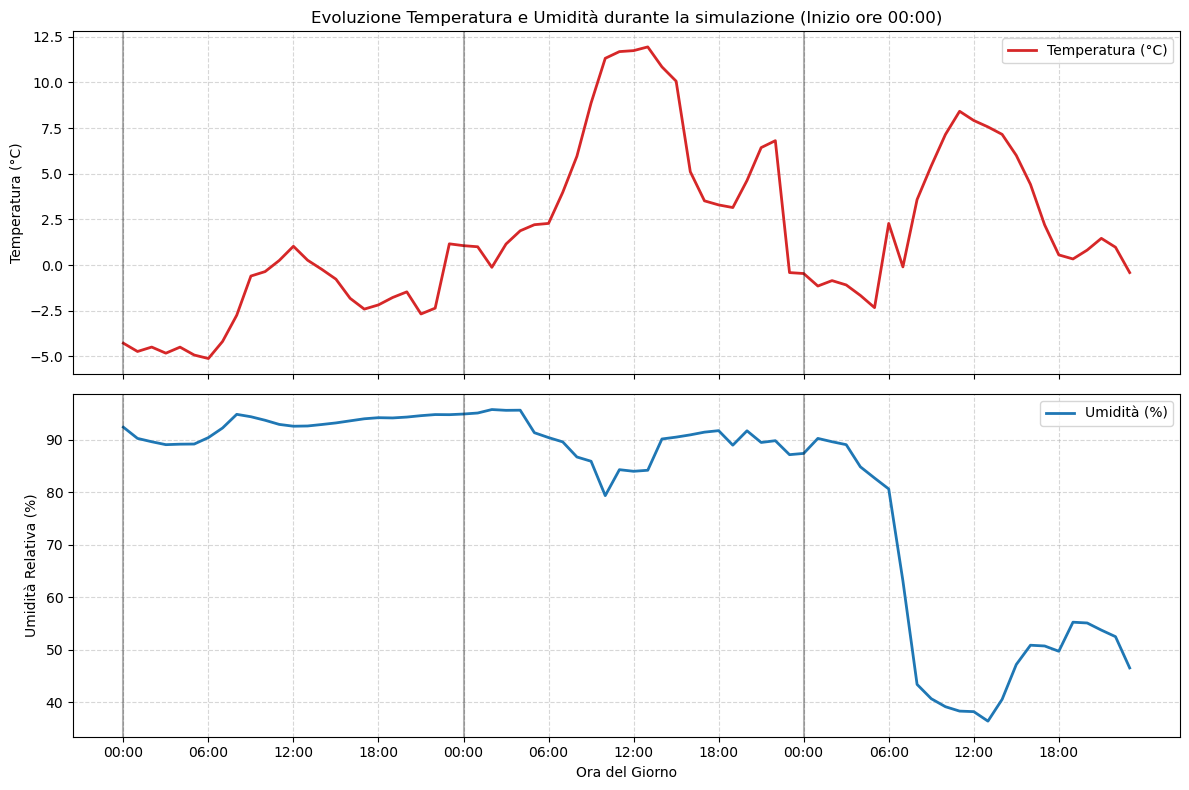

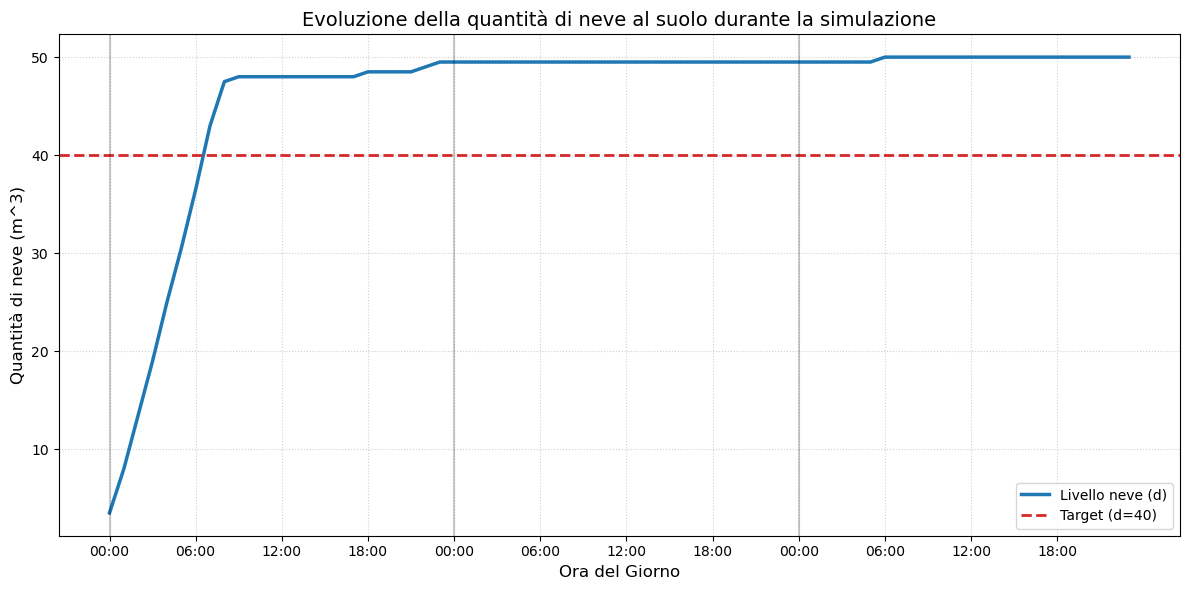

In [15]:
T_horiz = 72
simulation_results=simulate(T_horiz,d0=0,policy=optimal_policy,print_enabled=True)[0]
plot_weather_simulation(simulation_results,f_t0=0)
plot_snow_depth(simulation_results,f_t0=0)

Effettuazione di multiple simulazioni e plot dei risultati ottenuti.

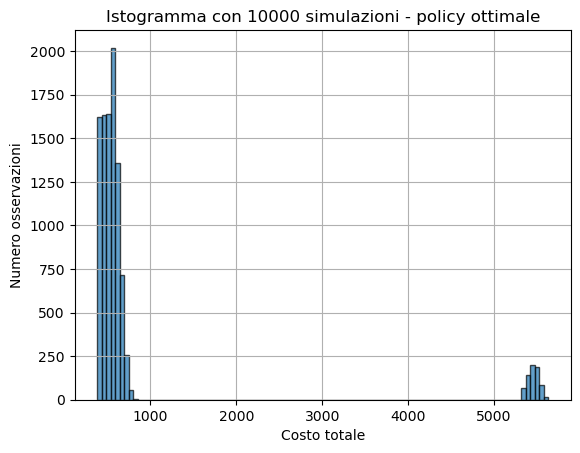

In [16]:
num_simulations = int(1e4)
total_costs_vector = np.empty(num_simulations)

def run_simulations(total_costs_vector, num_simulations):
    for i in range(num_simulations):
        total_costs_vector[i] = simulate(72,0,optimal_policy)[1]

run_simulations(total_costs_vector, num_simulations)

plt.hist(total_costs_vector, bins=100, alpha=0.7, edgecolor="black")
plt.xlabel("Costo totale")
plt.ylabel("Numero osservazioni")
plt.title(f"Istogramma con {num_simulations} simulazioni - policy ottimale")
plt.grid(True)
plt.show()

In [17]:
print("Valore atteso del costo totale: "+str(np.mean(total_costs_vector).round(2))+" €")

Valore atteso del costo totale: 875.68 €


## Definizione policy euristica
---

In [18]:
def heuristic_policy(x_t):
    temp_t, hum_t, d_t = x_t[0], x_t[1], x_t[2]
    T_wb_soglia= -2.5 #°C
    wb_t = wet_bulb_temperature(temp_t, hum_t)
    if wb_t < T_wb_soglia:
        # Possiamo sparare neve
        if d_t < d_target:
            # Si spara il più possibile
            a_f = 27.0 # m^3/h
            w_f = 4.5 # m^3/h
            u_t = [a_f, w_f]
        else:
            # Siamo già a livello target anche se potremmo sparare
            u_t = [0.0, 0.0]
    else:
        # Non possiamo sparare
        u_t = [0.0, 0.0]
    return u_t

## Simulazione policy euristica
---

In [19]:
# - funzione per la simulazione del sistema 
def simulate_heuristic(T,d0,print_enabled=False):
    # --> T: lunghezza time horizon
    # --> d0: quantità di neve al suolo all'inizio del time horizon
    # --> policy: policy utilizzata per la selesione dell'ingresso del sistema
    X_sim=np.empty((T,3)) #lista degli stati visitati dal sistema durante la simulazione
    # INIZIALIZZAZIONE
    t0=0
    f_t0=t0%24 #fascia oraria a cui appartiene t0
    x_0=get_initial_state(f_t0,d0) #stato iniziale
    u_t0=heuristic_policy(x_0) #ingresso iniziale applicato in accordo alla policy euristica
    total_cost = stage_cost(x_0,u_t0) #stage cost iniziale
    # ITERAZIONI
    x_t=x_0
    u_t=u_t0
    f_t=f_t0
    for t in range(T):
        if print_enabled: print(f"time {t}, fascia {f_t}, T={x_t[0]:.2f} RH={x_t[1]:.2f}% d={x_t[2]:.2f}")
        #evoluzione delle componenti dello stato
        next_T, next_RH = weather_transition(x_t,f_t)
        next_d = depth_transition(x_t,u_t)
        #stato raggiunto all'istante di tempo t+1
        x_tp1 = np.array([next_T,next_RH,next_d],dtype=np.float32)
        X_sim[t]=x_tp1
        x_t=x_tp1
        f_t=(t+1)%24
        if t<=70:
            if print_enabled: print(f"--> ingresso: air_flow={u_t[0]:.2f} water_flow=={u_t[1]:.2f}\n")
            u_t=heuristic_policy(x_t)
            total_cost += stage_cost(x_t, u_t) #accumulazione stage cost
        else: #siamo alla fine del time horizon
            total_cost += terminal_cost(x_t) #accumulazione terminal cost
    if print_enabled: print(f"Costo totale: {total_cost:.2f}")
    return X_sim, total_cost

### Esecuzione simulazioni
---

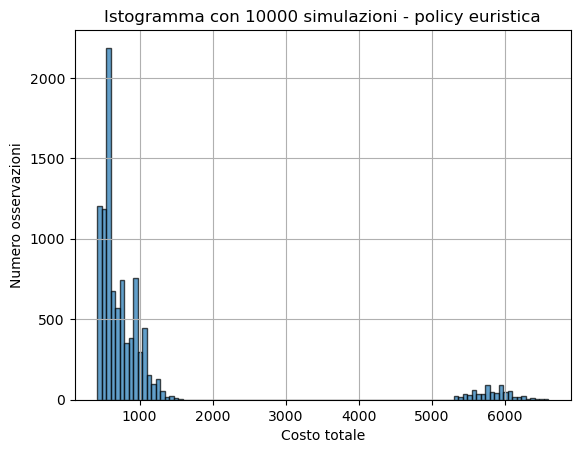

In [20]:
num_simulations = int(1e4)
total_costs_vector = np.empty(num_simulations)

def run_simulations(total_costs_vector, num_simulations):
    for i in range(num_simulations):
        total_costs_vector[i] = simulate_heuristic(72,0)[1]

run_simulations(total_costs_vector, num_simulations)

plt.hist(total_costs_vector, bins=100, alpha=0.7, edgecolor="black")
plt.xlabel("Costo totale")
plt.ylabel("Numero osservazioni")
plt.title(f"Istogramma con {num_simulations} simulazioni - policy euristica")
plt.grid(True)
plt.show()

In [21]:
print("Valore atteso del costo totale: "+str(np.mean(total_costs_vector).round(2))+" €")

Valore atteso del costo totale: 1056.68 €


## Analisi stazionarietà policy ottimale

--- Analisi Stazionarietà Policy (T=72) ---
1. Stazionarietà Stretta (t vs t+1): NO
   Max variazione step-to-step: 1.092826
2. Stazionarietà Periodica (t vs t+24): NO
   Max variazione periodica: 1.086619


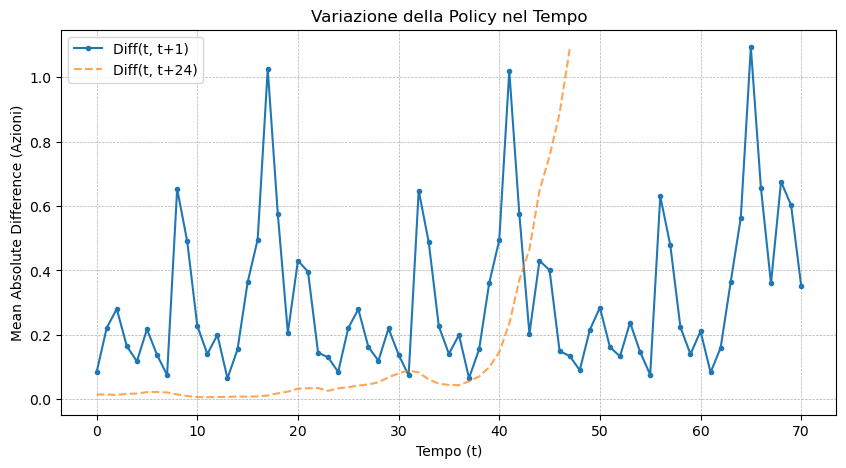

In [22]:
def analyze_policy_stationarity(policy, periodicity=24, tolerance=1e-5):
    """
    Analizza la stazionarietà di una policy di Dynamic Programming.
    
    Args:
        policy (np.ndarray): Tensore di forma (T, n_T, n_RH, n_d, 2)
        periodicity (int): Il periodo del ciclo (es. 24 ore) per controllare la ciclo-stazionarietà.
        tolerance (float): Soglia sotto la quale due azioni sono considerate uguali.
        
    Returns:
        dict: Dizionario contenente le metriche calcolate.
    """
    T, n_T, n_RH, n_d, n_u = policy.shape
    
    print(f"--- Analisi Stazionarietà Policy (T={T}) ---")
    
    # 1. Controllo Stazionarietà Stretta (t vs t+1)
    # Calcoliamo la norma della differenza tra istanti successivi
    diff_steps = []
    is_strictly_stationary = True
    
    for t in range(T - 1):
        # Calcola differenza assoluta media tra la policy al tempo t e t+1
        # Usiamo mean per avere un numero interpretabile indipendentemente dalle dimensioni griglia
        diff = np.mean(np.abs(policy[t] - policy[t+1]))
        diff_steps.append(diff)
        
        if diff > tolerance:
            is_strictly_stationary = False

    # 2. Controllo Stazionarietà Periodica (t vs t+periodo)
    # Utile per vedere se la policy a t=0 è uguale a t=24, t=48...
    diff_periodic = []
    is_periodically_stationary = True
    
    if T > periodicity:
        for t in range(T - periodicity):
            diff = np.mean(np.abs(policy[t] - policy[t + periodicity]))
            diff_periodic.append(diff)
            
            if diff > tolerance:
                is_periodically_stationary = False
    else:
        is_periodically_stationary = None
        print(f"Warning: Orizzonte temporale T={T} troppo breve per rilevare periodicità {periodicity}.")

    # --- Output Risultati ---
    print(f"1. Stazionarietà Stretta (t vs t+1): {'SI' if is_strictly_stationary else 'NO'}")
    print(f"   Max variazione step-to-step: {np.max(diff_steps):.6f}")
    
    if is_periodically_stationary is not None:
        print(f"2. Stazionarietà Periodica (t vs t+{periodicity}): {'SI' if is_periodically_stationary else 'NO'}")
        print(f"   Max variazione periodica: {np.max(diff_periodic):.6f}")

    # --- Plotting ---
    plt.figure(figsize=(10, 5))
    
    # Plot differenze step-to-step
    plt.plot(range(len(diff_steps)), diff_steps, label='Diff(t, t+1)', marker='o', markersize=3)
    
    # Plot differenze periodiche (se applicabile)
    if diff_periodic:
        plt.plot(range(len(diff_periodic)), diff_periodic, label=f'Diff(t, t+{periodicity})', linestyle='--', alpha=0.7)
    
    plt.title("Variazione della Policy nel Tempo")
    plt.xlabel("Tempo (t)")
    plt.ylabel("Mean Absolute Difference (Azioni)")
    plt.legend()
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.show()

    return {
        "strictly_stationary": is_strictly_stationary,
        "periodically_stationary": is_periodically_stationary,
        "diff_steps": np.array(diff_steps),
        "diff_periodic": np.array(diff_periodic) if diff_periodic else None
    }

# ESEMPIO DI UTILIZZO:
# Assicurati di aver calcolato mu_star_list prima di chiamare questa funzione
stats = analyze_policy_stationarity(optimal_policy, periodicity=24)

1. **La Linea Arancione Tratteggiata (Diff(t, t+24))**
Questa è la curva più significativa. Misura quanto la tua strategia oggi è diversa dalla strategia alla stessa ora di domani. Ci racconta una storia in due atti:

    **Fase 1**: La "Ciclo-Stazionarietà" (da t=0 a t≈30)
    
    La linea è quasi piatta e vicina allo zero.
    
    Significato: All'inizio dell'orizzonte temporale, la policy è "rilassata". Poiché mancano molte ore alla fine (T=72), il sistema si comporta in modo ciclico: l'azione ottima alle ore 8:00 del Giorno 1 è quasi identica all'azione ottima alle ore 8:00 del Giorno 2.
    
    Il sistema segue solo il meteo, che è periodico di 24 ore.

    **Fase 2**: L'Effetto "Orizzonte Finito" (da t>35 in poi)
    
    La linea schizza verso l'alto esponenzialmente.
    
    Significato: Qui il vincolo finale (d_target da raggiungere a T=72) inizia a dominare.
    
    Confrontiamo l'ora t=40 con l'ora t=64 (che è 40+24):
    
    A t=40 (mancano 32 ore), il sistema può permettersi di aspettare condizioni meteo ideali per fare neve a basso costo.
    
    A t=64 (mancano solo 8 ore), il sistema entra in modalità "panico": deve produrre neve per evitare la penalità finale, anche se fa caldo e costa molto.
    
    Quindi la strategia cambia drasticamente tra i due giorni perché l'urgenza è diversa.

2. **La Linea Blu Continua (Diff(t, t+1))**
    Questa curva misura quanto cambia la decisione da un'ora all'altra.
    
    Perché oscilla così tanto (i picchi)?
    
    Questi picchi rappresentano i momenti della giornata in cui il meteo cambia rapidamente (es. l'alba o il tramonto) o attraversa la soglia critica del Wet Bulb Temperature.
    
    Se alle 10:00 fa freddo e alle 11:00 la temperatura sale appena sopra lo zero, la policy ottima si "ribalta" completamente per quasi tutti gli stati: da ON passa a OFF. Questo genera un picco di differenza alto.
    
    I picchi sembrano ripetersi con una certa regolarità (nota come i picchi alti sono distanziati circa di 12-24 ore), confermando che seguono il ciclo giorno/notte.

**Sintesi Fisica**
    Il grafico ti sta dicendo questo:
    
    "Se mancano molti giorni alla scadenza, mi comporto sempre allo stesso modo ogni giorno (Linea Arancione bassa). Ma man mano che si avvicina la scadenza finale, smetto di guardare solo l'efficienza energetica e inizio a forzare la produzione per raggiungere l'obiettivo, deviando dal mio comportamento standard (Linea Arancione impenna)."